## Daily Weather from Top 10 Major Indian Cities, 2000-2024
### Detailed EDA at City Level Part 2: Differences Between Real and Apparent Temperatures

#### Import Libraries and set path

In [3]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates

In [4]:
path = r'C:\Users\artoe\Documents\DataAnalytics\projects\india weather\archive'

#### Import data as pickle

In [6]:
df = pd.read_pickle(os.path.join(path, 'daily_weather_updated.pkl'))

### Create Columns for Difference Between Apparent and Real Temperatures

We will calculate this by subtracting the real temperatures (min and max) from apparent ones.

E.g. 

Real Min. Temp: 23°C
Apparent Min. Temp: 19°C
Temp_Diff_Min: 19-23 = -4°C 
the apparent minimum temperature is 4 degrees colder than the actual temperature.

Real Max. Temp: 36°C
Apparent Max. Temp: 41°C
Temp_Diff_Max: 41-36 = 5°C
the apparent maximum temperature is 5 degrees warmer than the actual temperature.

In [8]:
#creating column for minimum temperature difference
df['temp_diff_min'] = df['apparent_temperature_min']-df['temperature_2m_min']

In [9]:
#creating column for maximum temperature difference
df['temp_diff_max'] = df['apparent_temperature_max']-df['temperature_2m_max']

In [10]:
#creating column for mean temperature difference
df['temp_diff_mean'] = df['apparent_temperature_mean']-df['temperature_2m_mean']

In [11]:
#check columns for correctness
df[['temperature_2m_min', 'apparent_temperature_min', 'temp_diff_min']].head()

,temperature_2m_min,apparent_temperature_min,temp_diff_min
0,7.4,5.8,-1.6
1,5.5,3.4,-2.1
2,6.3,4.3,-2.0
3,6.4,4.2,-2.2
4,5.3,3.2,-2.1


In [12]:
df[['temperature_2m_max', 'apparent_temperature_max', 'temp_diff_max']].head()

,temperature_2m_max,apparent_temperature_max,temp_diff_max
0,19.9,19.2,-0.7
1,20.0,18.9,-1.1
2,20.1,18.2,-1.9
3,19.8,18.5,-1.3
4,19.4,17.7,-1.7


In [13]:
df[['temperature_2m_mean', 'apparent_temperature_mean', 'temp_diff_mean']].head()

,temperature_2m_mean,apparent_temperature_mean,temp_diff_mean
0,13.65,12.50,-1.15
1,12.75,11.15,-1.60
2,13.20,11.25,-1.95
3,13.10,11.35,-1.75
4,12.35,10.45,-1.90


In [14]:
#aggregate both these variables by month
df['temp_diff_min_monthly'] = df.groupby(['month_year','city'])['temp_diff_min'].transform(np.mean)

C:\Users\artoe\AppData\Local\Temp\ipykernel_16660\2465122723.py:2: FutureWarning: The provided callable <function mean at 0x0000021673BB8FE0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['temp_diff_min_monthly'] = df.groupby(['month_year','city'])['temp_diff_min'].transform(np.mean)


In [15]:
df['temp_diff_max_monthly'] = df.groupby(['month_year','city'])['temp_diff_max'].transform(np.mean)

C:\Users\artoe\AppData\Local\Temp\ipykernel_16660\1061080706.py:1: FutureWarning: The provided callable <function mean at 0x0000021673BB8FE0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['temp_diff_max_monthly'] = df.groupby(['month_year','city'])['temp_diff_max'].transform(np.mean)


In [16]:
df['temp_diff_mean_monthly'] = df.groupby(['month_year','city'])['temp_diff_mean'].transform(np.mean)

C:\Users\artoe\AppData\Local\Temp\ipykernel_16660\1840529172.py:1: FutureWarning: The provided callable <function mean at 0x0000021673BB8FE0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['temp_diff_mean_monthly'] = df.groupby(['month_year','city'])['temp_diff_mean'].transform(np.mean)


#### Create a Date column in numeric format for plotting purposes

In [18]:
df['date_numeric'] = mdates.date2num(df['date'])

In [19]:
df[['date', 'date_numeric']].head()

,date,date_numeric
0,2000-01-01,10957.0
1,2000-01-02,10958.0
2,2000-01-03,10959.0
3,2000-01-04,10960.0
4,2000-01-05,10961.0


In [20]:
#export updated data-set to pickle
df.to_pickle(os.path.join(path, 'daily_weather_updated_2.pkl'))

### Create Subsets for Each City

In [22]:
#find list of cities
df['city'].value_counts()

city
Delhi        9132
Mumbai       9132
Kolkata      9132
Chennai      9132
Bangalore    9132
Hyderabad    9132
Ahmedabad    9132
Pune         9132
Jaipur       9132
Lucknow      9132
Name: count, dtype: int64

In [23]:
#create a subset for each city
df_delhi =  df[df['city']=='Delhi']
df_mumbai =  df[df['city']=='Mumbai']
df_kolkata =  df[df['city']=='Kolkata']
df_chennai =  df[df['city']=='Chennai']
df_bangalore =  df[df['city']=='Bangalore']
df_hyderabad =  df[df['city']=='Hyderabad']
df_ahmedabad =  df[df['city']=='Ahmedabad']
df_pune =  df[df['city']=='Pune']
df_jaipur =  df[df['city']=='Jaipur']
df_lucknow =  df[df['city']=='Lucknow']

## Delhi

#### Daily Minimum and Maximum Temperature Difference (Monthly Average)

In [26]:
melted_minmax_delhi = df_delhi.melt(
    id_vars='month_year',
    value_vars=['temp_diff_min_monthly', 'temp_diff_max_monthly'],
    var_name="Temperature_Level",
    value_name='Temp_Diff',
)

In [27]:
melted_minmax_delhi['Temperature_Level'] = melted_minmax_delhi['Temperature_Level'].replace(
    {'temp_diff_min_monthly': 'Difference between Apparent and Real Daily Minimum', 'temp_diff_max_monthly': 'Difference between Apparent and Real Daily Maximum'}
)

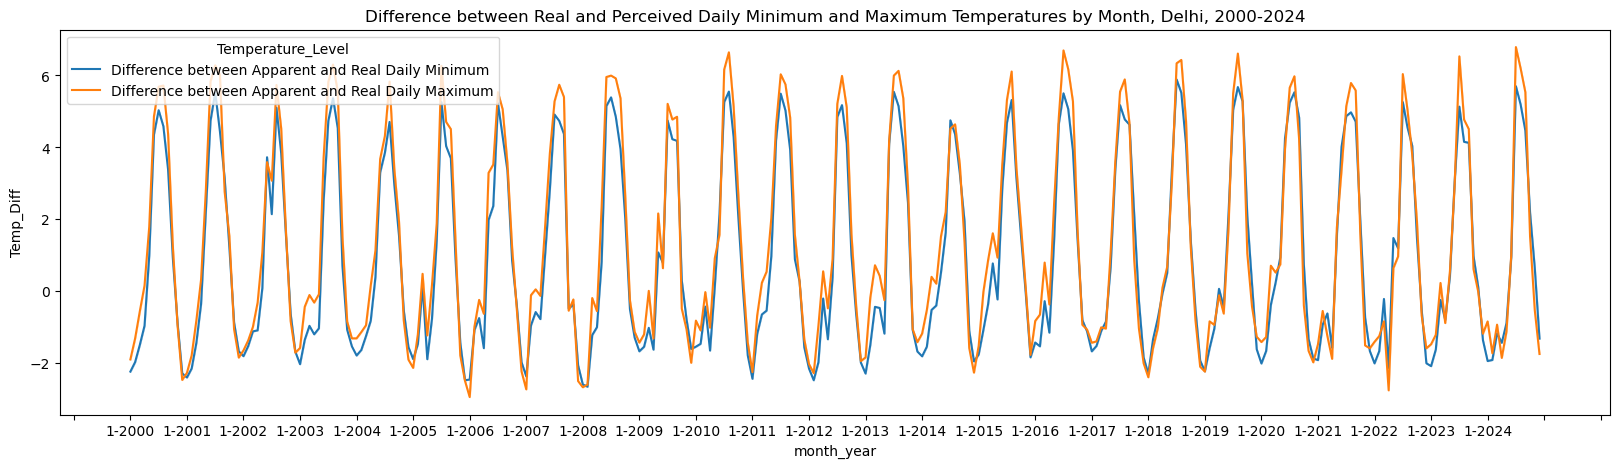

In [28]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_delhi, x='month_year', y='Temp_Diff', hue='Temperature_Level')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Minimum and Maximum Temperatures by Month, Delhi, 2000-2024')
plt.show()

#### Daily Mean Temperature Difference (Monthly Average) in Delhi, 2000-2024

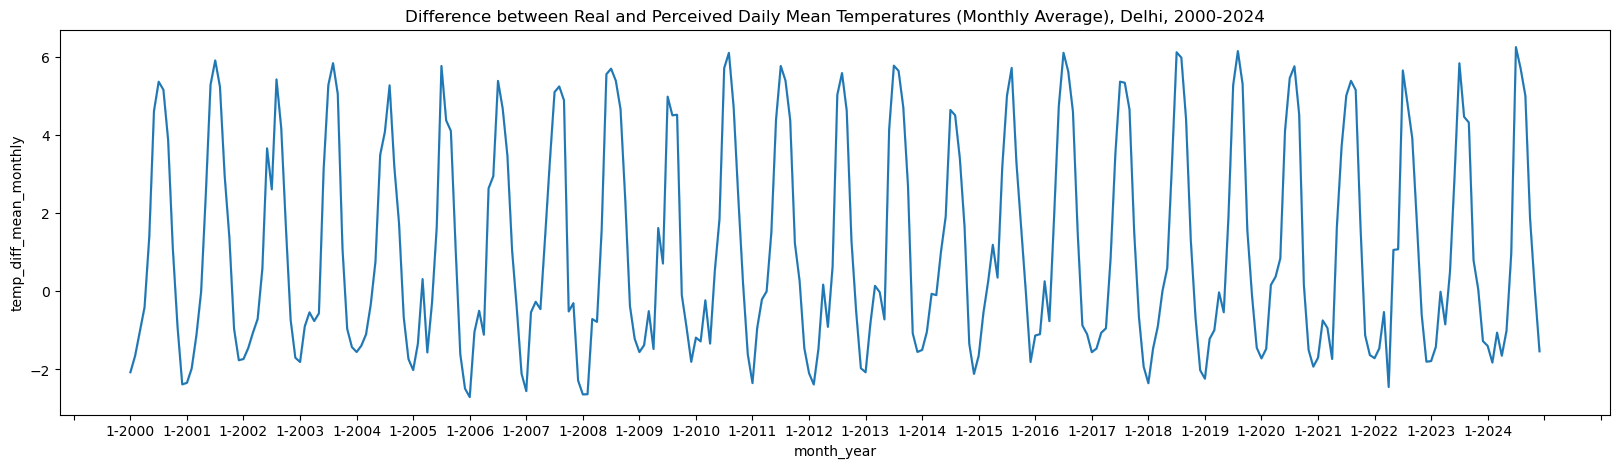

In [30]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_delhi, x='month_year', y='temp_diff_mean_monthly')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Mean Temperatures (Monthly Average), Delhi, 2000-2024')
plt.show()

#### Finding Trends in Temperature Differences

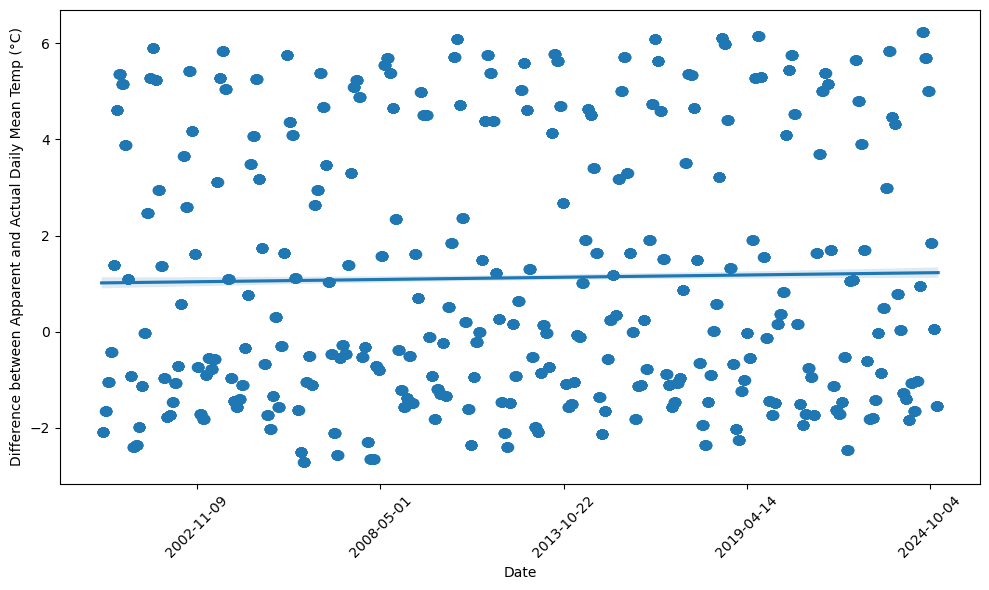

In [32]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df_delhi, x='date_numeric', y='temp_diff_mean_monthly')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set(xlabel='Date', ylabel='Difference between Apparent and Actual Daily Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Mumbai

#### Daily Minimum and Maximum Temperature Difference (Monthly Average)

In [35]:
melted_minmax_mumbai = df_mumbai.melt(
    id_vars='month_year',
    value_vars=['temp_diff_min_monthly', 'temp_diff_max_monthly'],
    var_name="Temperature_Level",
    value_name='Temp_Diff',
)

In [36]:
melted_minmax_mumbai['Temperature_Level'] = melted_minmax_mumbai['Temperature_Level'].replace(
    {'temp_diff_min_monthly': 'Difference between Apparent and Real Daily Minimum', 'temp_diff_max_monthly': 'Difference between Apparent and Real Daily Maximum'}
)

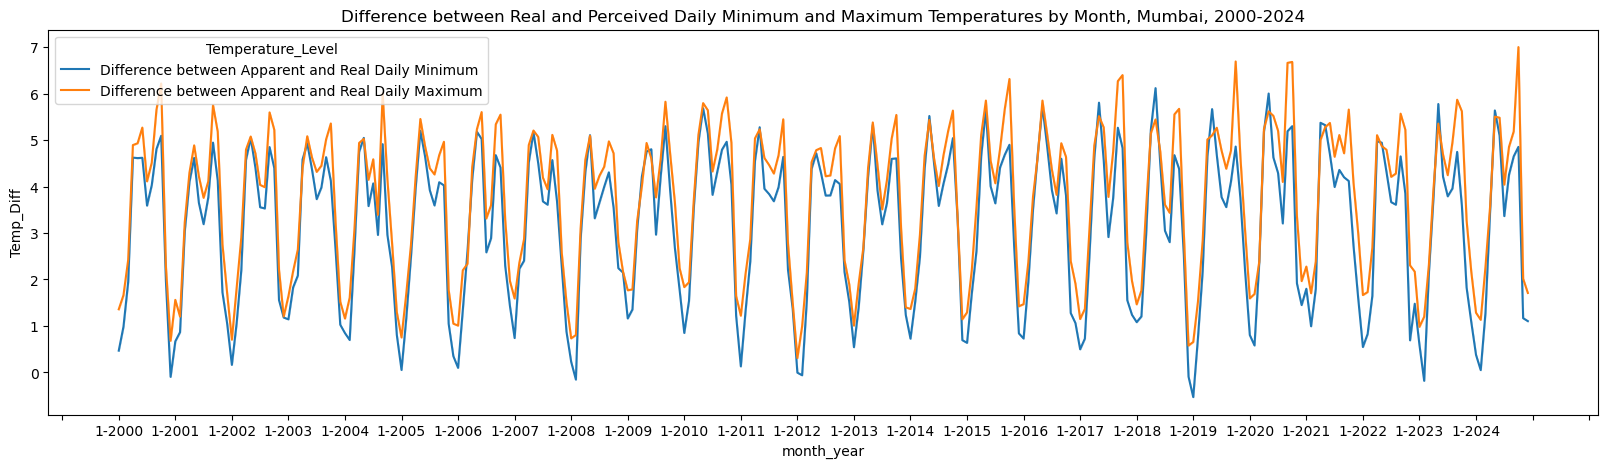

In [37]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_mumbai, x='month_year', y='Temp_Diff', hue='Temperature_Level')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Minimum and Maximum Temperatures by Month, Mumbai, 2000-2024')
plt.show()

#### Daily Mean Temperature Difference by Month, 2000-2024

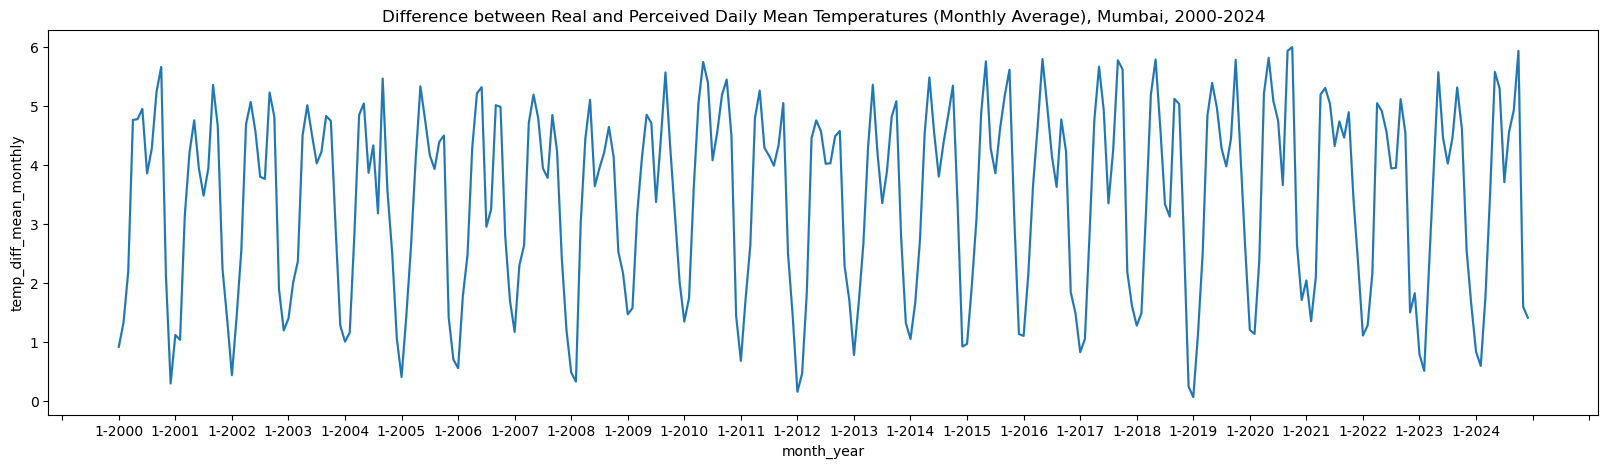

In [39]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_mumbai, x='month_year', y='temp_diff_mean_monthly')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Mean Temperatures (Monthly Average), Mumbai, 2000-2024')
plt.show()

#### Finding Trends in Temperature Differences

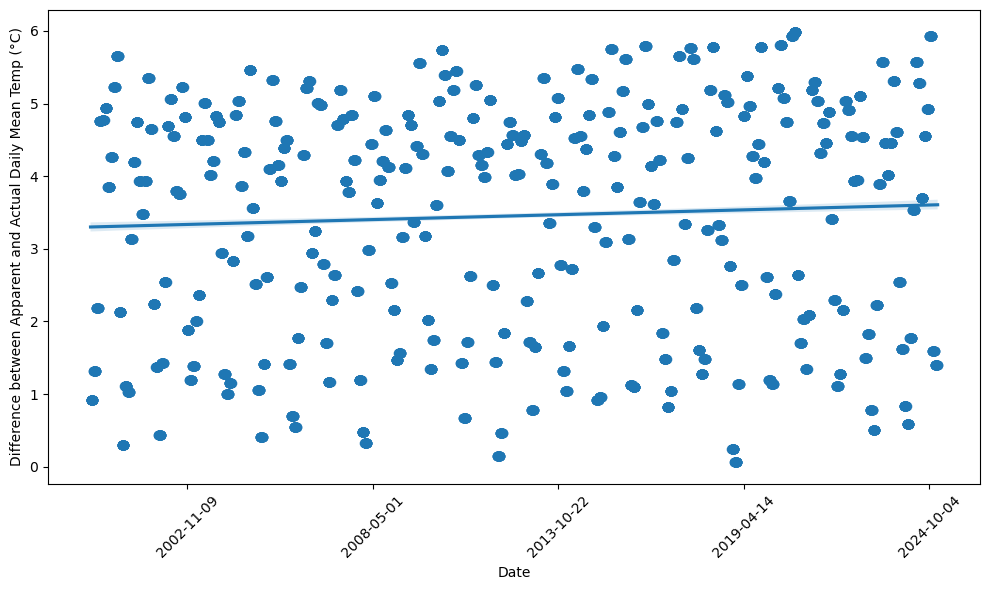

In [41]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df_mumbai, x='date_numeric', y='temp_diff_mean_monthly')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set(xlabel='Date', ylabel='Difference between Apparent and Actual Daily Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Kolkata

#### Daily Minimum and Maximum Temperature Difference (Monthly Average)

In [44]:
melted_minmax_kolkata = df_kolkata.melt(
    id_vars='month_year',
    value_vars=['temp_diff_min_monthly', 'temp_diff_max_monthly'],
    var_name="Temperature_Level",
    value_name='Temp_Diff',
)

In [45]:
melted_minmax_kolkata['Temperature_Level'] = melted_minmax_kolkata['Temperature_Level'].replace(
    {'temp_diff_min_monthly': 'Difference between Apparent and Real Daily Minimum', 'temp_diff_max_monthly': 'Difference between Apparent and Real Daily Maximum'}
)

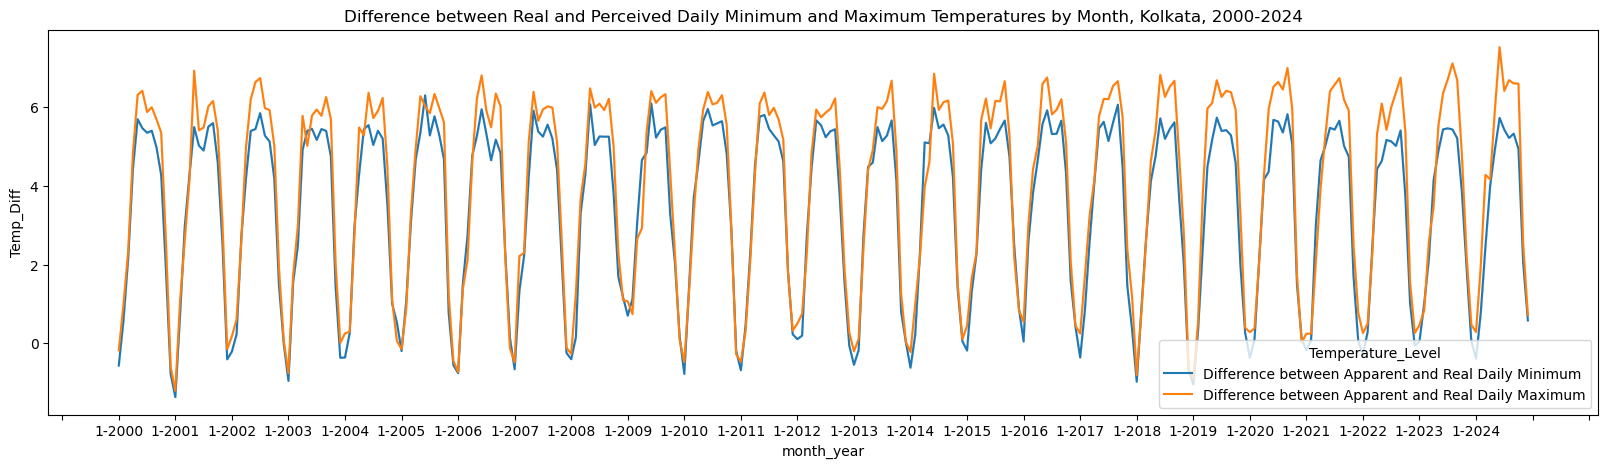

In [46]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_kolkata, x='month_year', y='Temp_Diff', hue='Temperature_Level')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Minimum and Maximum Temperatures by Month, Kolkata, 2000-2024')
plt.show()

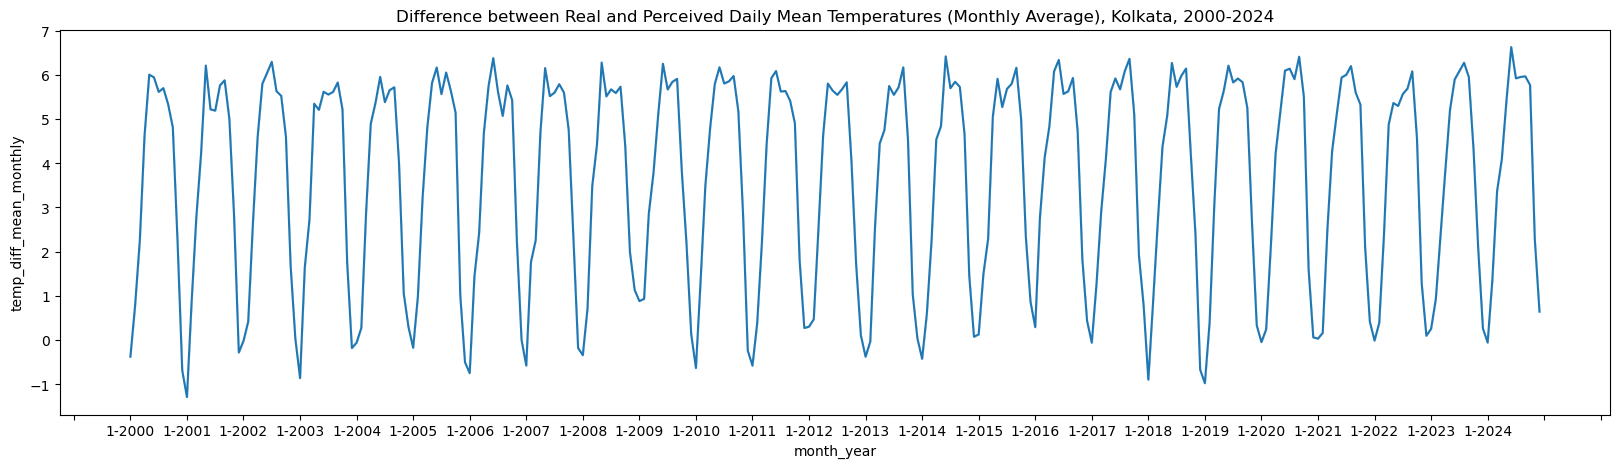

In [47]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_kolkata, x='month_year', y='temp_diff_mean_monthly')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Mean Temperatures (Monthly Average), Kolkata, 2000-2024')
plt.show()

#### Finding Trends in Temperature Differences

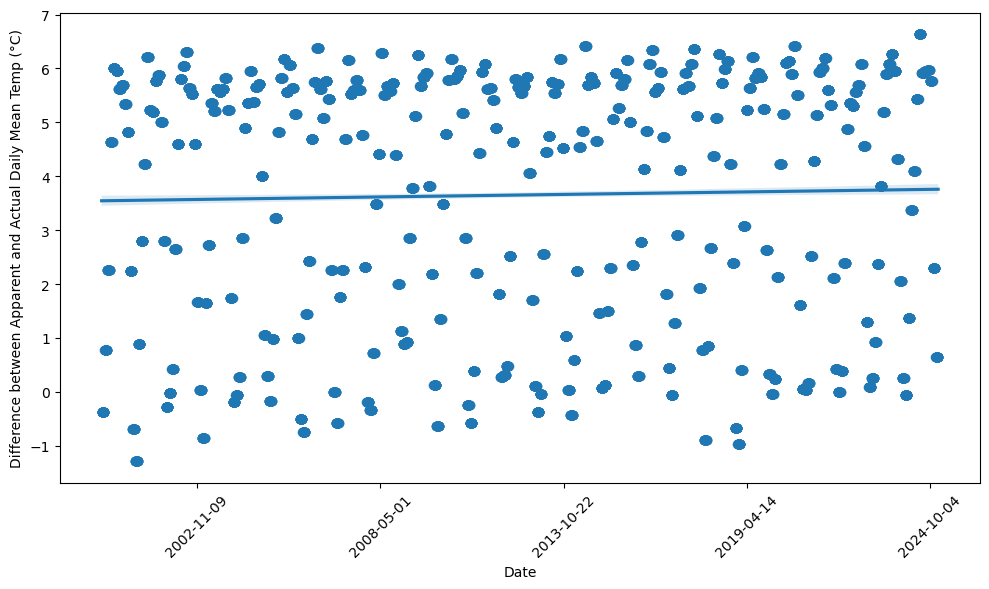

In [49]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df_kolkata, x='date_numeric', y='temp_diff_mean_monthly')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set(xlabel='Date', ylabel='Difference between Apparent and Actual Daily Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Chennai

#### Daily Minimum and Maximum Temperature Difference (Monthly Average)

In [52]:
melted_minmax_chennai = df_chennai.melt(
    id_vars='month_year',
    value_vars=['temp_diff_min_monthly', 'temp_diff_max_monthly'],
    var_name="Temperature_Level",
    value_name='Temp_Diff',
)

In [53]:
melted_minmax_chennai['Temperature_Level'] = melted_minmax_chennai['Temperature_Level'].replace(
    {'temp_diff_min_monthly': 'Difference between Apparent and Real Daily Minimum', 'temp_diff_max_monthly': 'Difference between Apparent and Real Daily Maximum'}
)

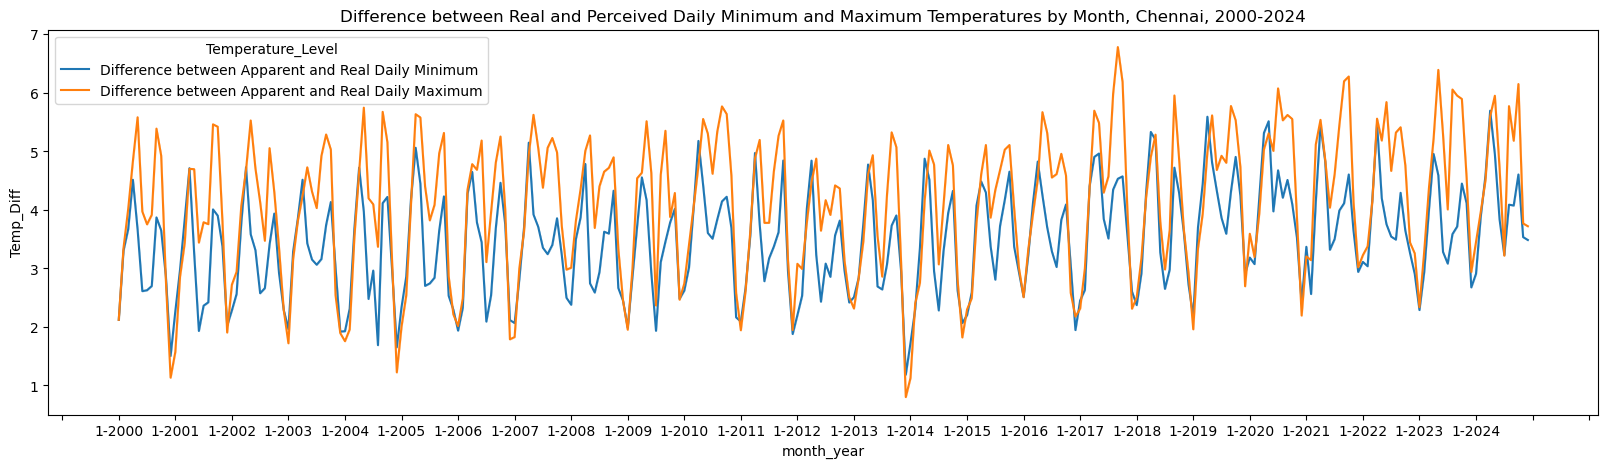

In [54]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_chennai, x='month_year', y='Temp_Diff', hue='Temperature_Level')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Minimum and Maximum Temperatures by Month, Chennai, 2000-2024')
plt.show()

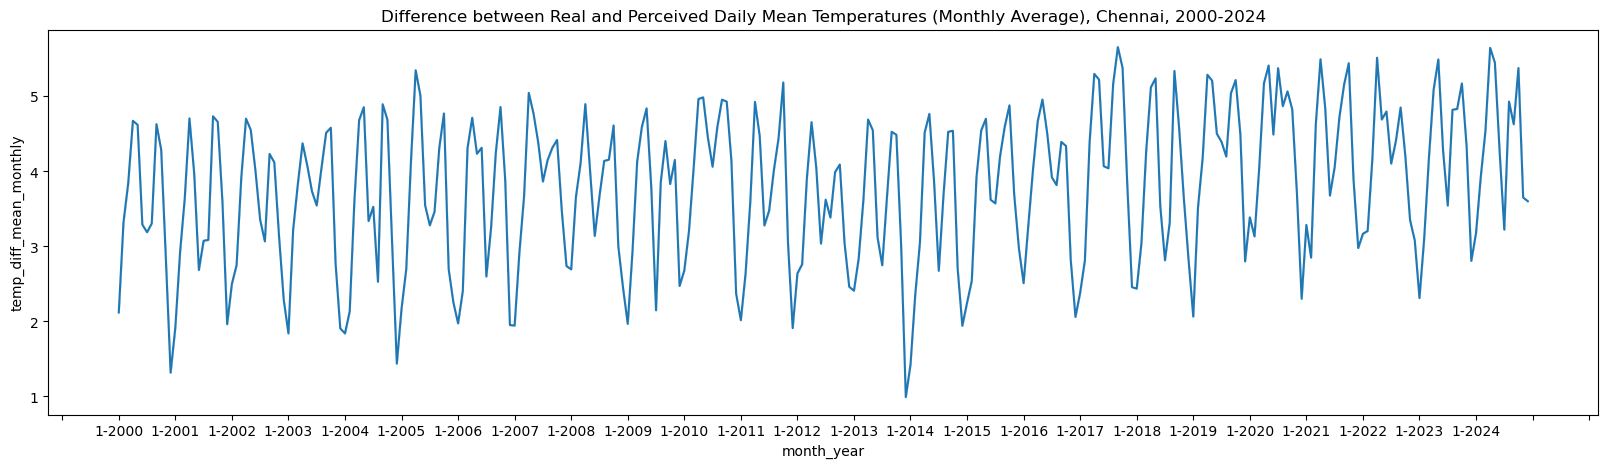

In [55]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_chennai, x='month_year', y='temp_diff_mean_monthly')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Mean Temperatures (Monthly Average), Chennai, 2000-2024')
plt.show()

#### Finding Trends in Temperature Differences

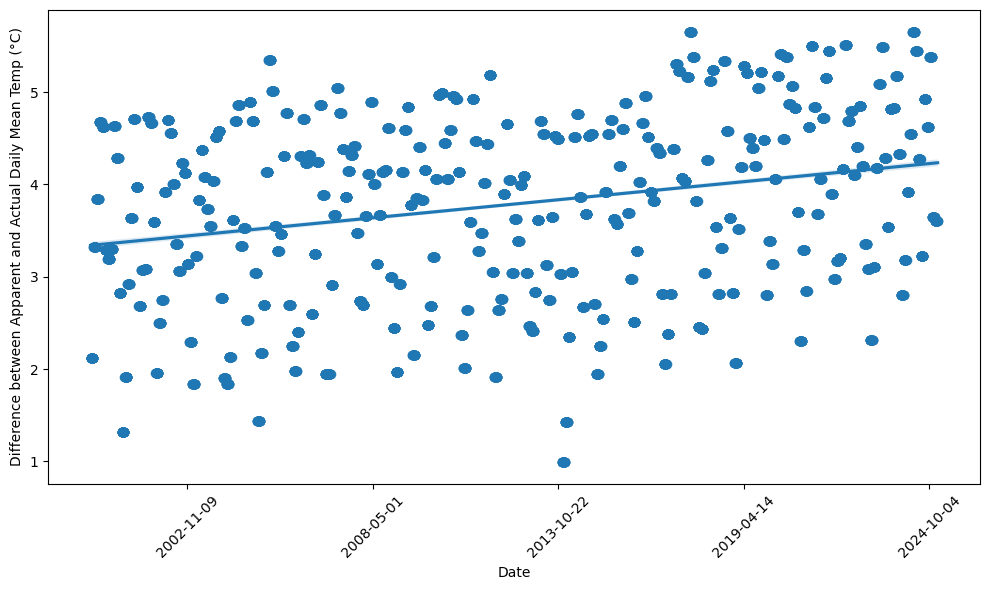

In [57]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df_chennai, x='date_numeric', y='temp_diff_mean_monthly')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set(xlabel='Date', ylabel='Difference between Apparent and Actual Daily Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bangalore

#### Daily Minimum and Maximum Temperature Difference (Monthly Average)

In [60]:
melted_minmax_bangalore = df_bangalore.melt(
    id_vars='month_year',
    value_vars=['temp_diff_min_monthly', 'temp_diff_max_monthly'],
    var_name="Temperature_Level",
    value_name='Temp_Diff',
)

In [61]:
melted_minmax_bangalore['Temperature_Level'] = melted_minmax_bangalore['Temperature_Level'].replace(
    {'temp_diff_min_monthly': 'Difference between Apparent and Real Daily Minimum', 'temp_diff_max_monthly': 'Difference between Apparent and Real Daily Maximum'}
)

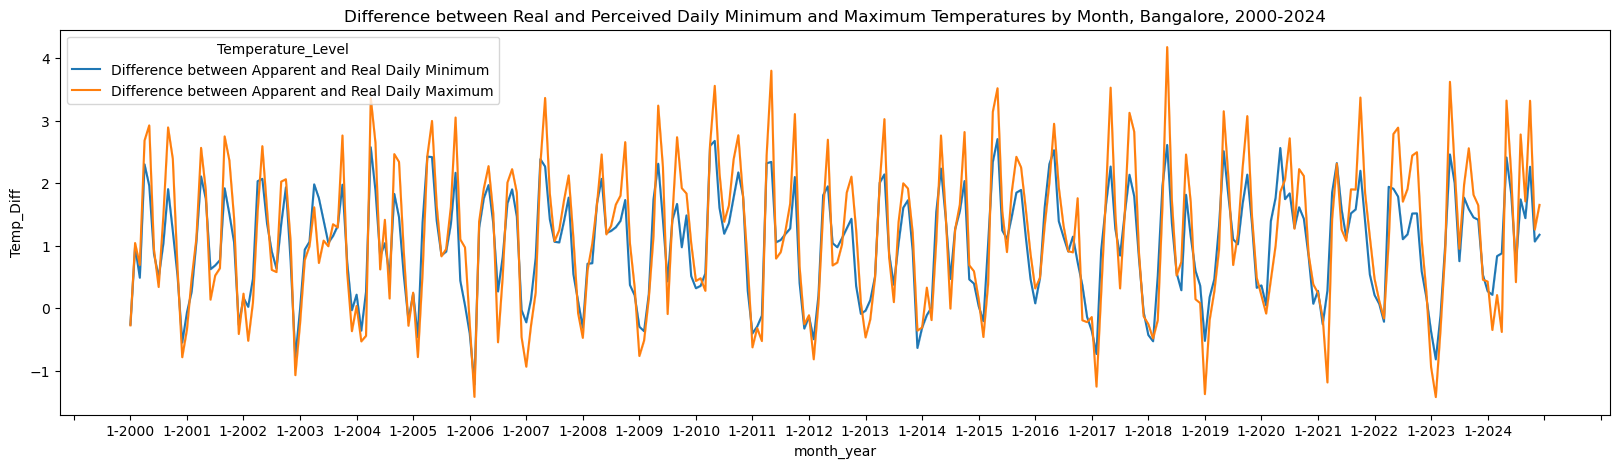

In [62]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_bangalore, x='month_year', y='Temp_Diff', hue='Temperature_Level')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Minimum and Maximum Temperatures by Month, Bangalore, 2000-2024')
plt.show()

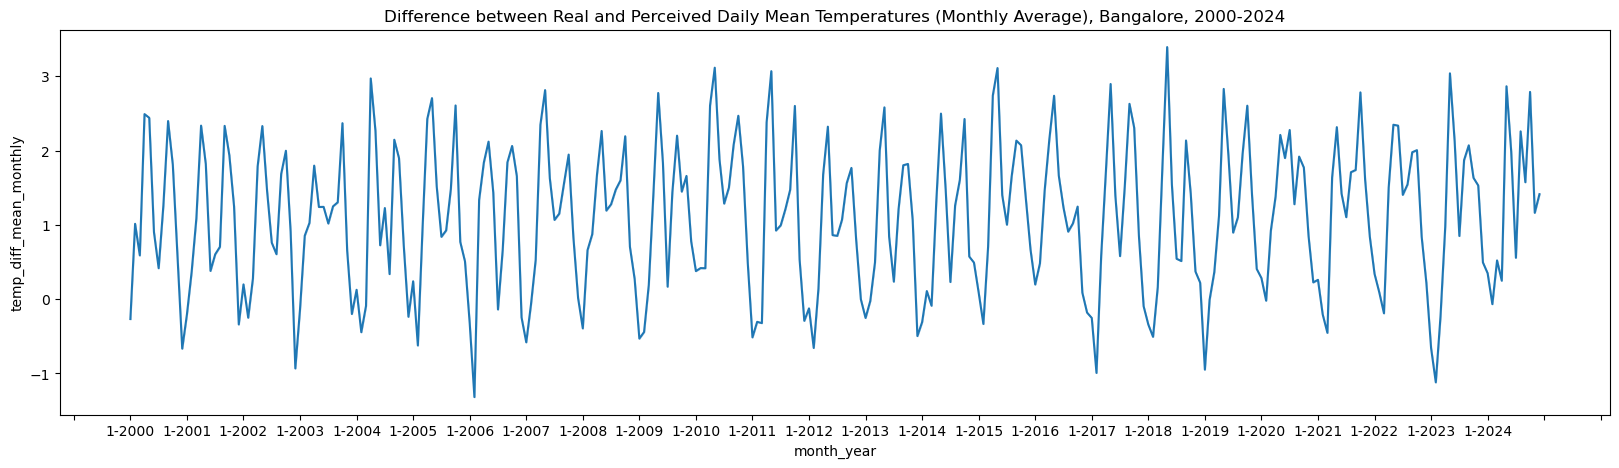

In [63]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_bangalore, x='month_year', y='temp_diff_mean_monthly')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Mean Temperatures (Monthly Average), Bangalore, 2000-2024')
plt.show()

#### Finding Trends in Temperature Differences

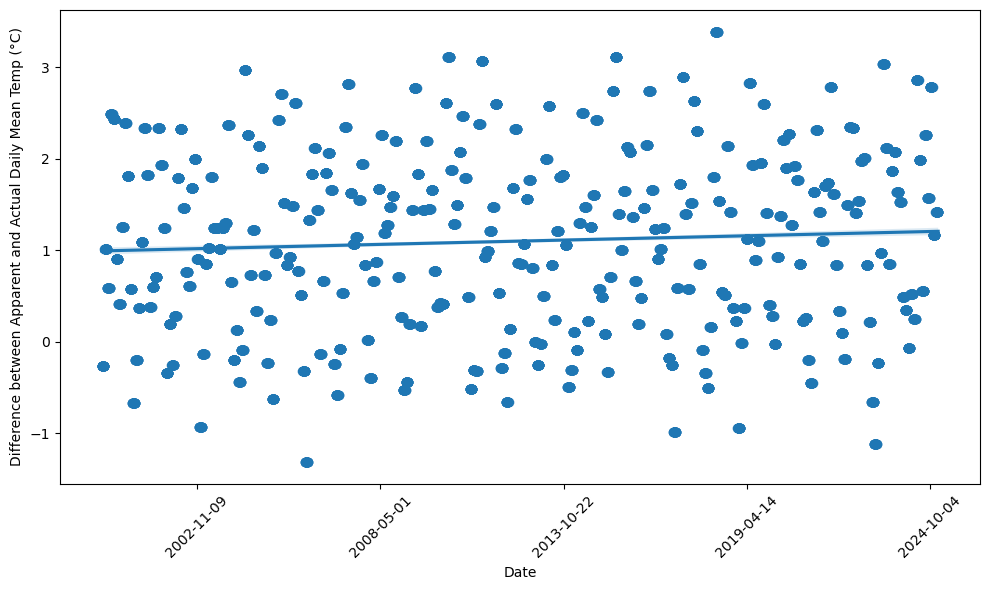

In [65]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df_bangalore, x='date_numeric', y='temp_diff_mean_monthly')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set(xlabel='Date', ylabel='Difference between Apparent and Actual Daily Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hyderabad

#### Daily Minimum and Maximum Temperature Difference (Monthly Average)

In [68]:
melted_minmax_hyderabad = df_hyderabad.melt(
    id_vars='month_year',
    value_vars=['temp_diff_min_monthly', 'temp_diff_max_monthly'],
    var_name="Temperature_Level",
    value_name='Temp_Diff',
)

In [69]:
melted_minmax_hyderabad['Temperature_Level'] = melted_minmax_hyderabad['Temperature_Level'].replace(
    {'temp_diff_min_monthly': 'Difference between Apparent and Real Daily Minimum', 'temp_diff_max_monthly': 'Difference between Apparent and Real Daily Maximum'}
)

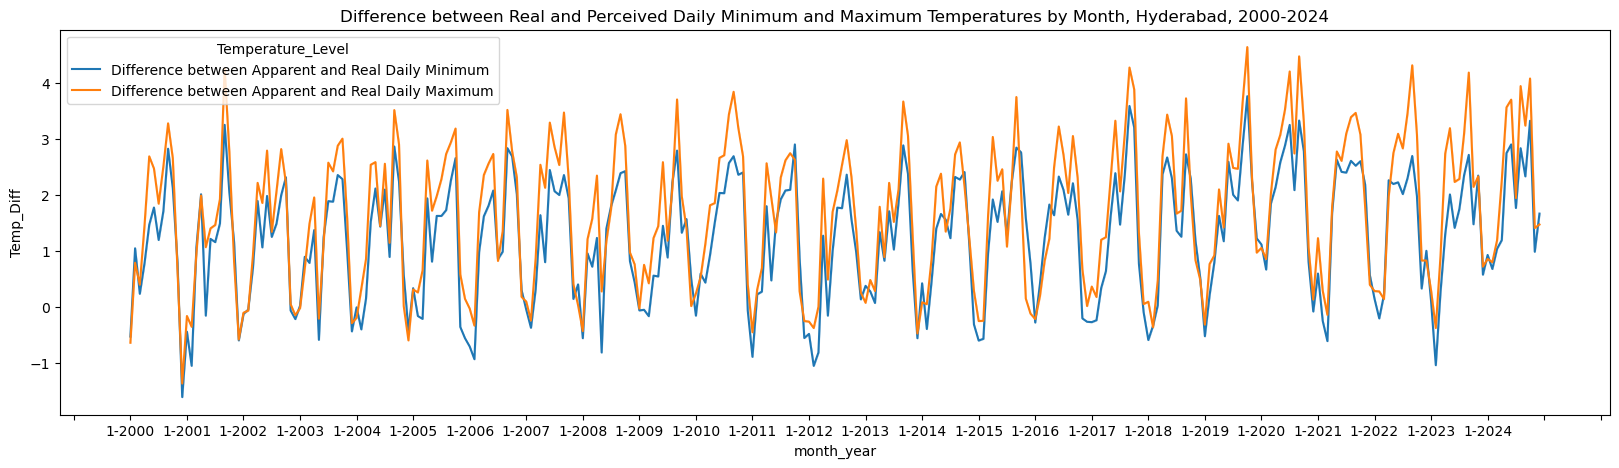

In [70]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_hyderabad, x='month_year', y='Temp_Diff', hue='Temperature_Level')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Minimum and Maximum Temperatures by Month, Hyderabad, 2000-2024')
plt.show()

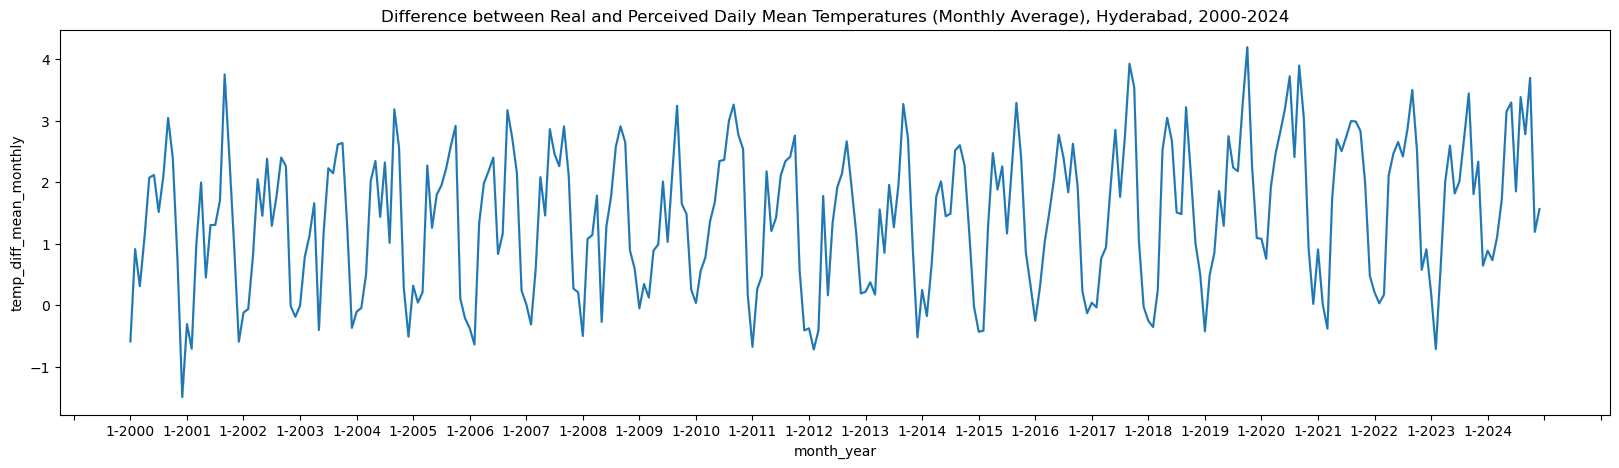

In [71]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_hyderabad, x='month_year', y='temp_diff_mean_monthly')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Mean Temperatures (Monthly Average), Hyderabad, 2000-2024')
plt.show()

#### Finding Trends in Temperature Differences

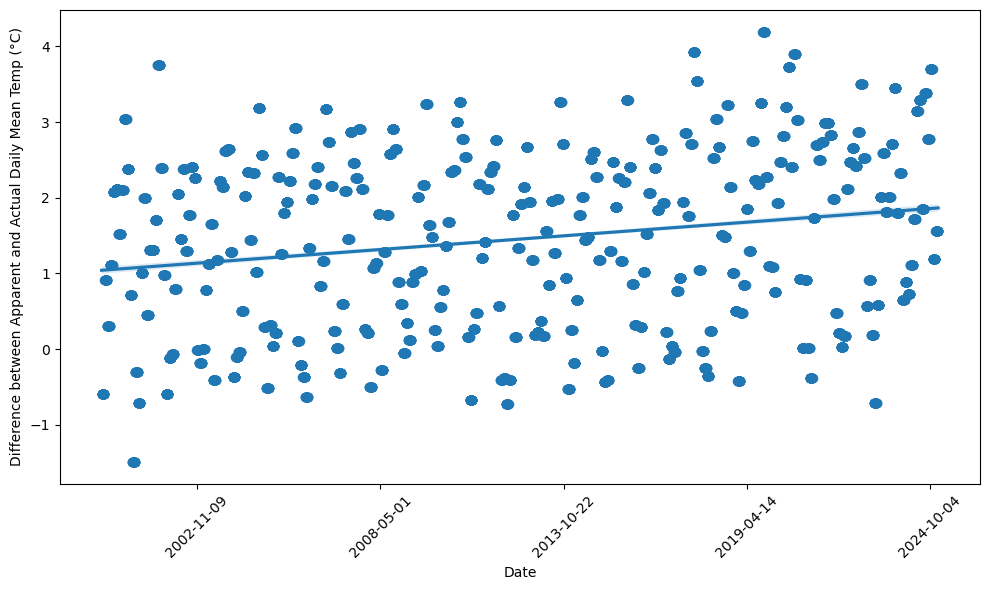

In [73]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df_hyderabad, x='date_numeric', y='temp_diff_mean_monthly')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set(xlabel='Date', ylabel='Difference between Apparent and Actual Daily Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Ahmedabad

#### Daily Minimum and Maximum Temperature Difference (Monthly Average)

In [76]:
melted_minmax_ahmedabad = df_ahmedabad.melt(
    id_vars='month_year',
    value_vars=['temp_diff_min_monthly', 'temp_diff_max_monthly'],
    var_name="Temperature_Level",
    value_name='Temp_Diff',
)

In [77]:
melted_minmax_ahmedabad['Temperature_Level'] = melted_minmax_ahmedabad['Temperature_Level'].replace(
    {'temp_diff_min_monthly': 'Difference between Apparent and Real Daily Minimum', 'temp_diff_max_monthly': 'Difference between Apparent and Real Daily Maximum'}
)

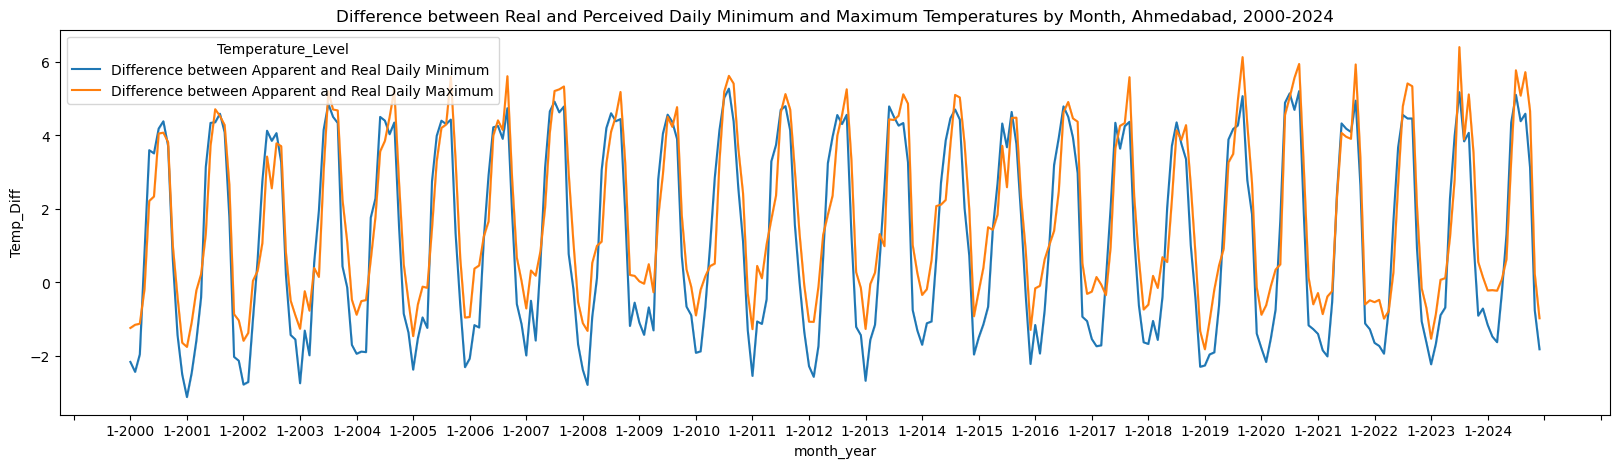

In [78]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_ahmedabad, x='month_year', y='Temp_Diff', hue='Temperature_Level')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Minimum and Maximum Temperatures by Month, Ahmedabad, 2000-2024')
plt.show()

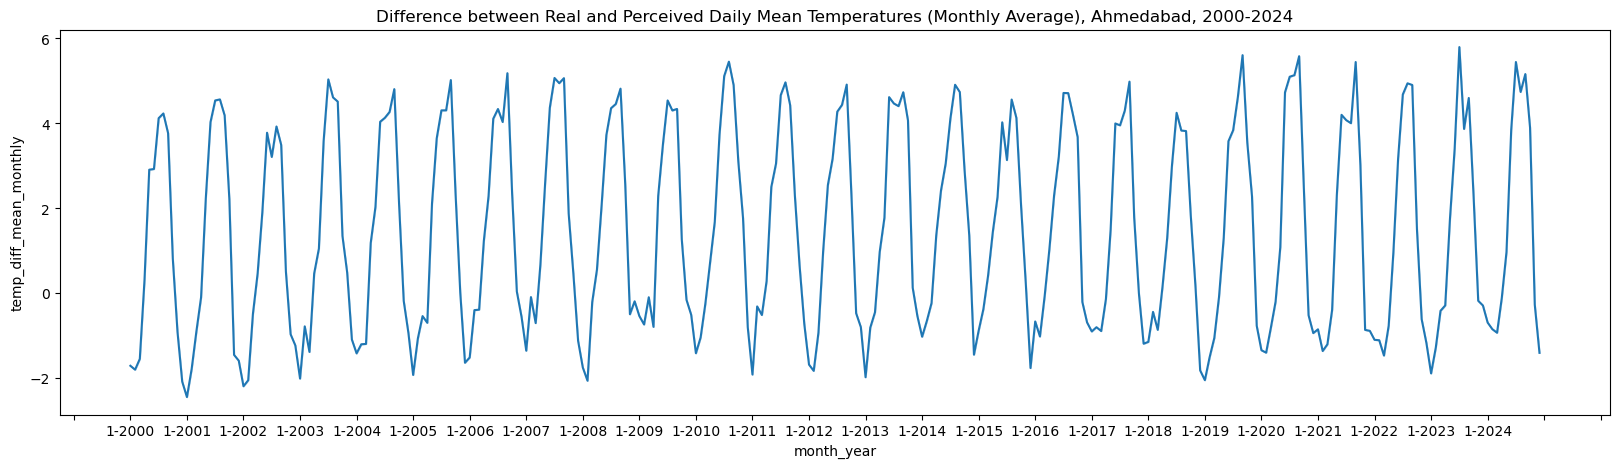

In [79]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_ahmedabad, x='month_year', y='temp_diff_mean_monthly')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Mean Temperatures (Monthly Average), Ahmedabad, 2000-2024')
plt.show()

#### Finding Trends in Temperature Differences

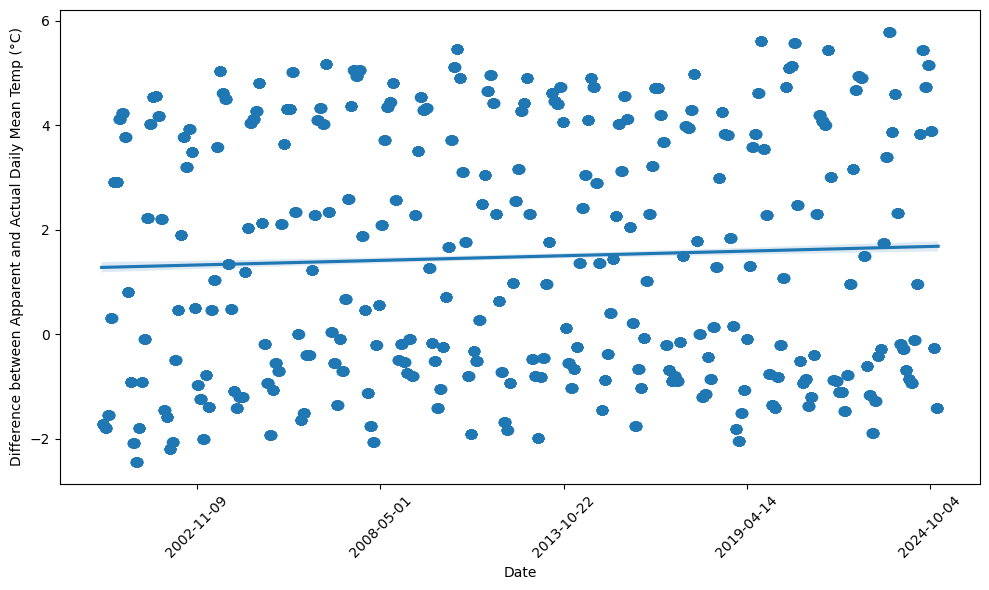

In [81]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df_ahmedabad, x='date_numeric', y='temp_diff_mean_monthly')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set(xlabel='Date', ylabel='Difference between Apparent and Actual Daily Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Pune

#### Daily Minimum and Maximum Temperature Difference (Monthly Average)

In [84]:
melted_minmax_pune = df_pune.melt(
    id_vars='month_year',
    value_vars=['temp_diff_min_monthly', 'temp_diff_max_monthly'],
    var_name="Temperature_Level",
    value_name='Temp_Diff',
)

In [85]:
melted_minmax_pune['Temperature_Level'] = melted_minmax_pune['Temperature_Level'].replace(
    {'temp_diff_min_monthly': 'Difference between Apparent and Real Daily Minimum', 'temp_diff_max_monthly': 'Difference between Apparent and Real Daily Maximum'}
)

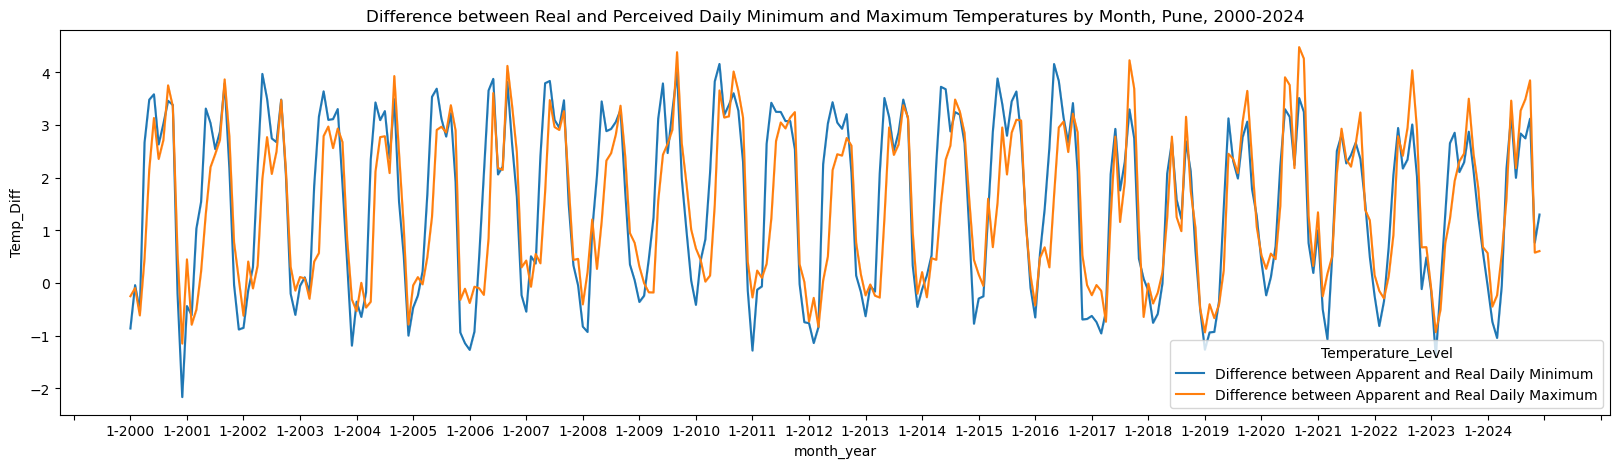

In [86]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_pune, x='month_year', y='Temp_Diff', hue='Temperature_Level')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Minimum and Maximum Temperatures by Month, Pune, 2000-2024')
plt.show()

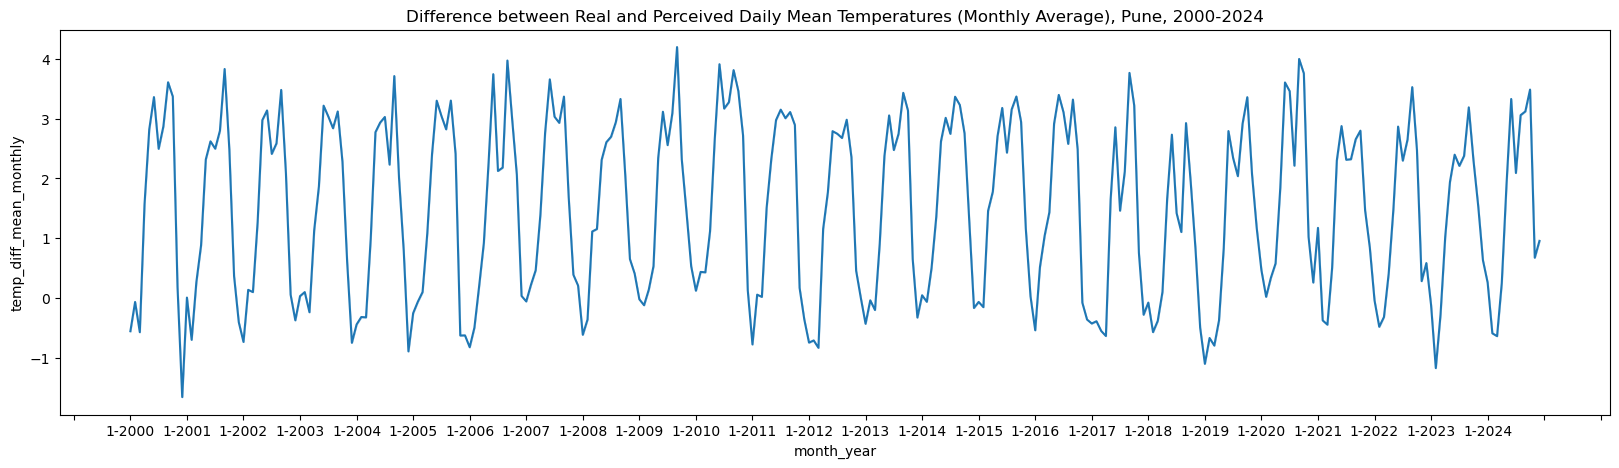

In [87]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_pune, x='month_year', y='temp_diff_mean_monthly')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Mean Temperatures (Monthly Average), Pune, 2000-2024')
plt.show()

#### Finding Trends in Temperature Differences

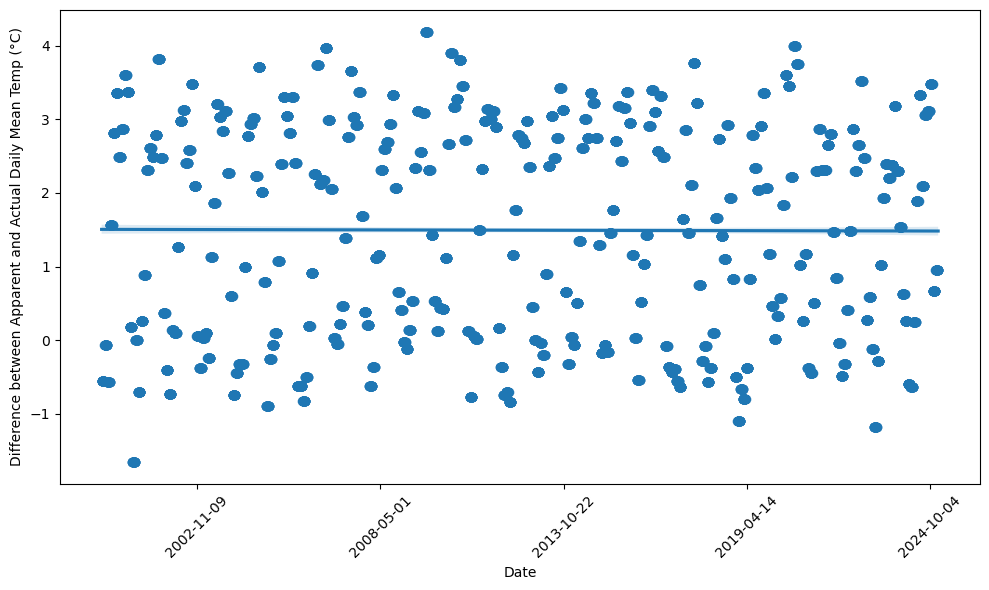

In [89]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df_pune, x='date_numeric', y='temp_diff_mean_monthly')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set(xlabel='Date', ylabel='Difference between Apparent and Actual Daily Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Jaipur

#### Daily Minimum and Maximum Temperature Difference (Monthly Average)

In [92]:
melted_minmax_jaipur = df_jaipur.melt(
    id_vars='month_year',
    value_vars=['temp_diff_min_monthly', 'temp_diff_max_monthly'],
    var_name="Temperature_Level",
    value_name='Temp_Diff',
)

In [93]:
melted_minmax_jaipur['Temperature_Level'] = melted_minmax_jaipur['Temperature_Level'].replace(
    {'temp_diff_min_monthly': 'Difference between Apparent and Real Daily Minimum', 'temp_diff_max_monthly': 'Difference between Apparent and Real Daily Maximum'}
)

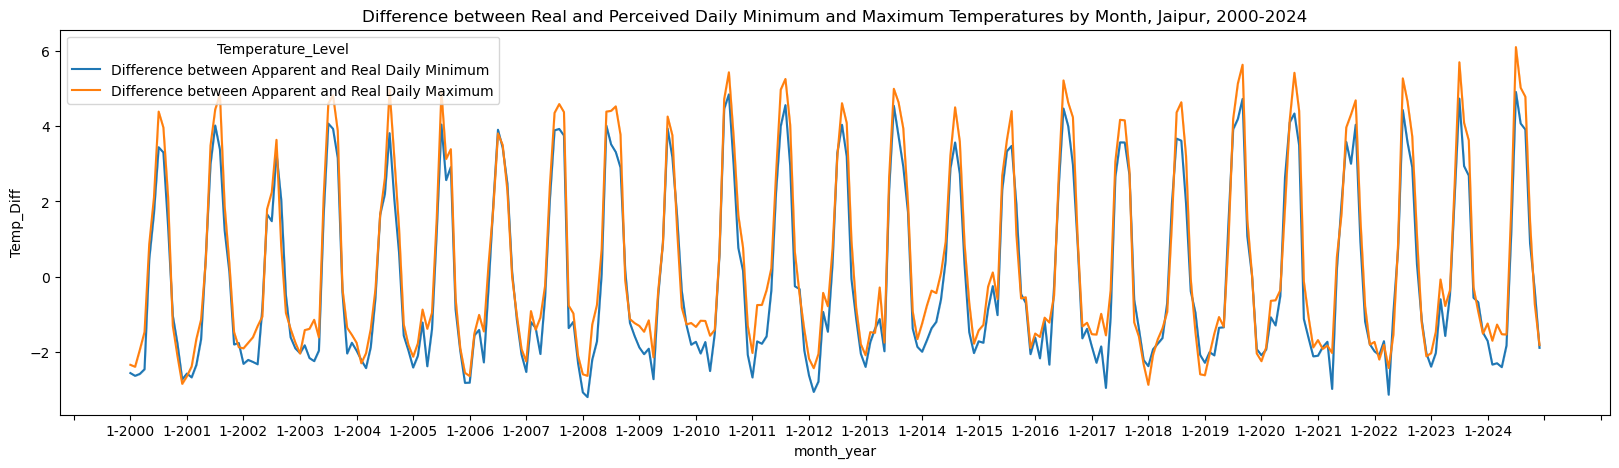

In [94]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_jaipur, x='month_year', y='Temp_Diff', hue='Temperature_Level')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Minimum and Maximum Temperatures by Month, Jaipur, 2000-2024')
plt.show()

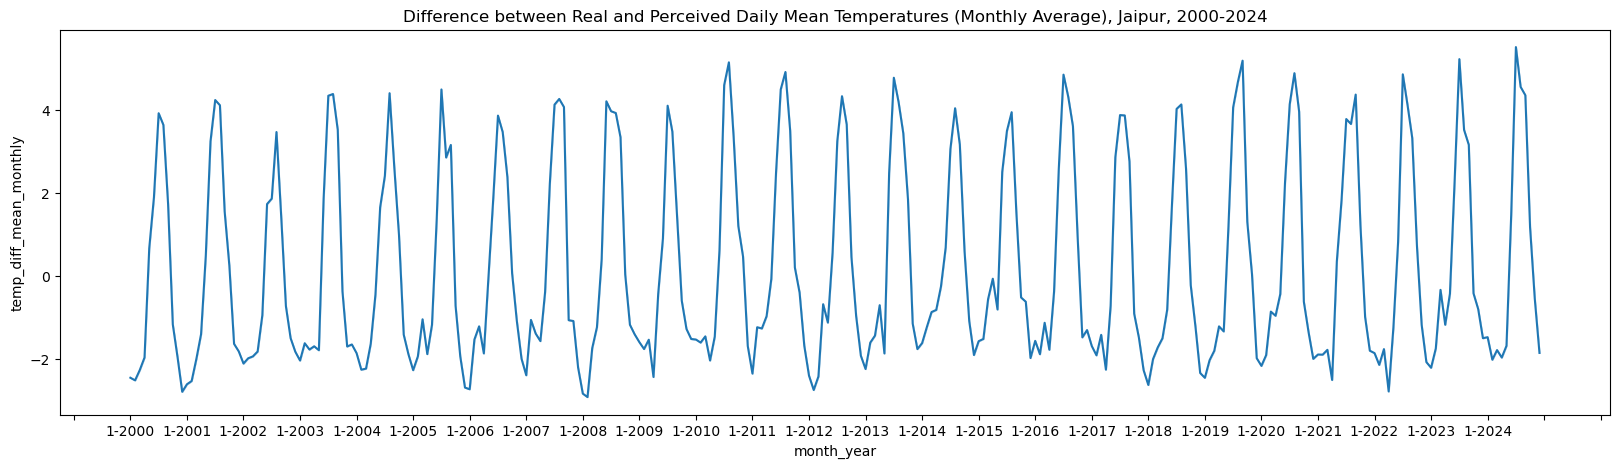

In [95]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_jaipur, x='month_year', y='temp_diff_mean_monthly')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Mean Temperatures (Monthly Average), Jaipur, 2000-2024')
plt.show()

#### Finding Trends in Temperature Differences

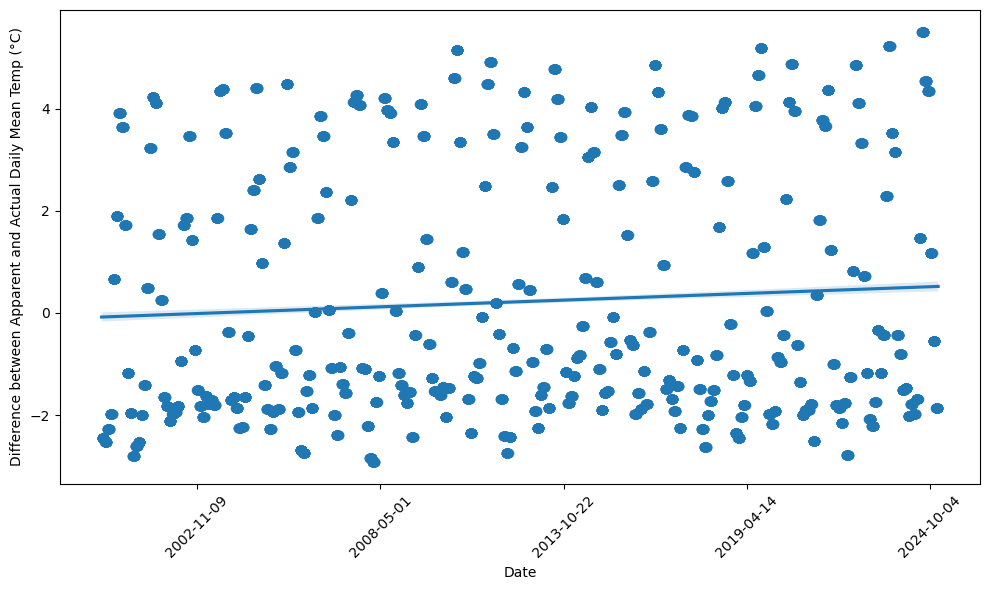

In [97]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df_jaipur, x='date_numeric', y='temp_diff_mean_monthly')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set(xlabel='Date', ylabel='Difference between Apparent and Actual Daily Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Lucknow

#### Daily Minimum and Maximum Temperature Difference (Monthly Average)

In [100]:
melted_minmax_lucknow = df_lucknow.melt(
    id_vars='month_year',
    value_vars=['temp_diff_min_monthly', 'temp_diff_max_monthly'],
    var_name="Temperature_Level",
    value_name='Temp_Diff',
)

In [101]:
melted_minmax_lucknow['Temperature_Level'] = melted_minmax_lucknow['Temperature_Level'].replace(
    {'temp_diff_min_monthly': 'Difference between Apparent and Real Daily Minimum', 'temp_diff_max_monthly': 'Difference between Apparent and Real Daily Maximum'}
)

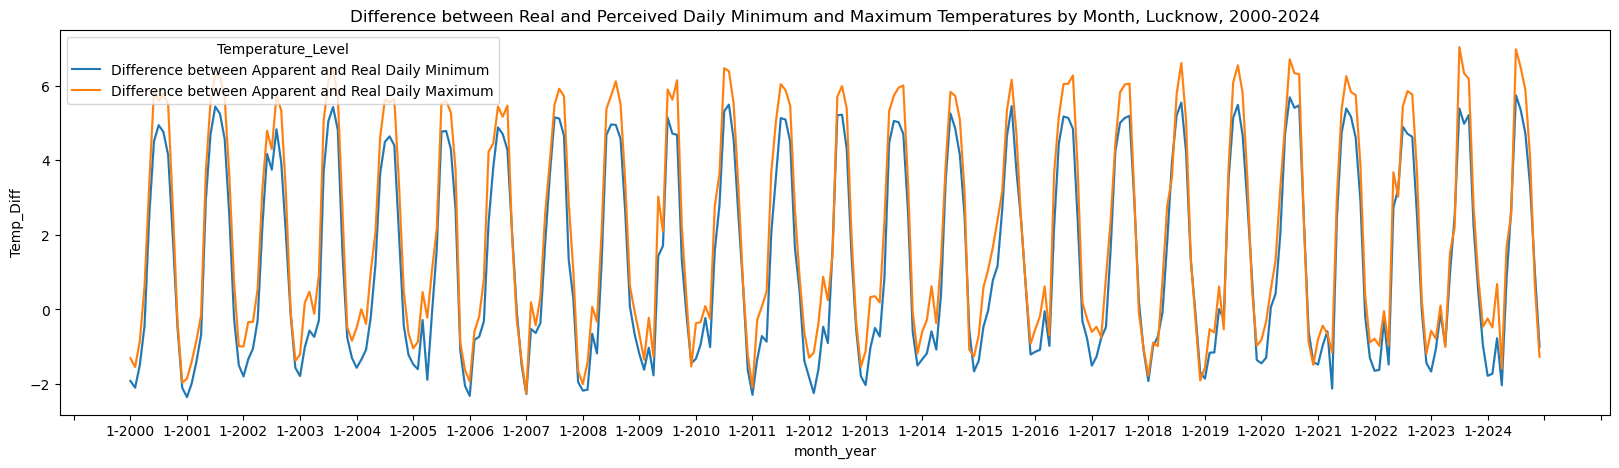

In [102]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_lucknow, x='month_year', y='Temp_Diff', hue='Temperature_Level')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Minimum and Maximum Temperatures by Month, Lucknow, 2000-2024')
plt.show()

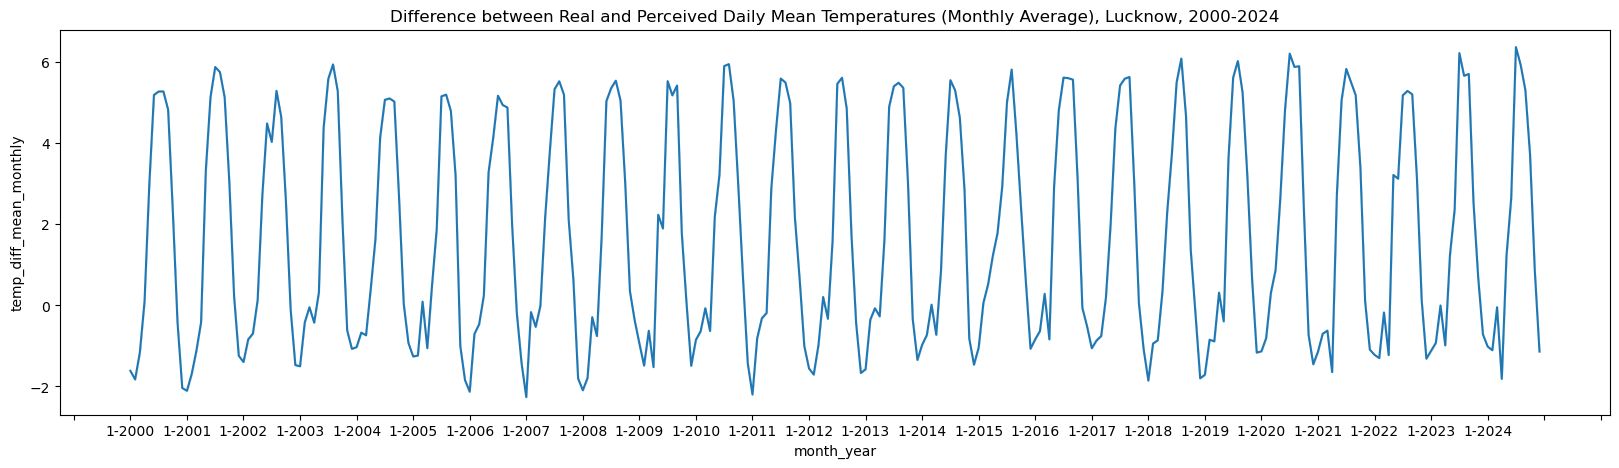

In [103]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_lucknow, x='month_year', y='temp_diff_mean_monthly')
ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
plt.title('Difference between Real and Perceived Daily Mean Temperatures (Monthly Average), Lucknow, 2000-2024')
plt.show()

#### Finding Trends in Temperature Differences

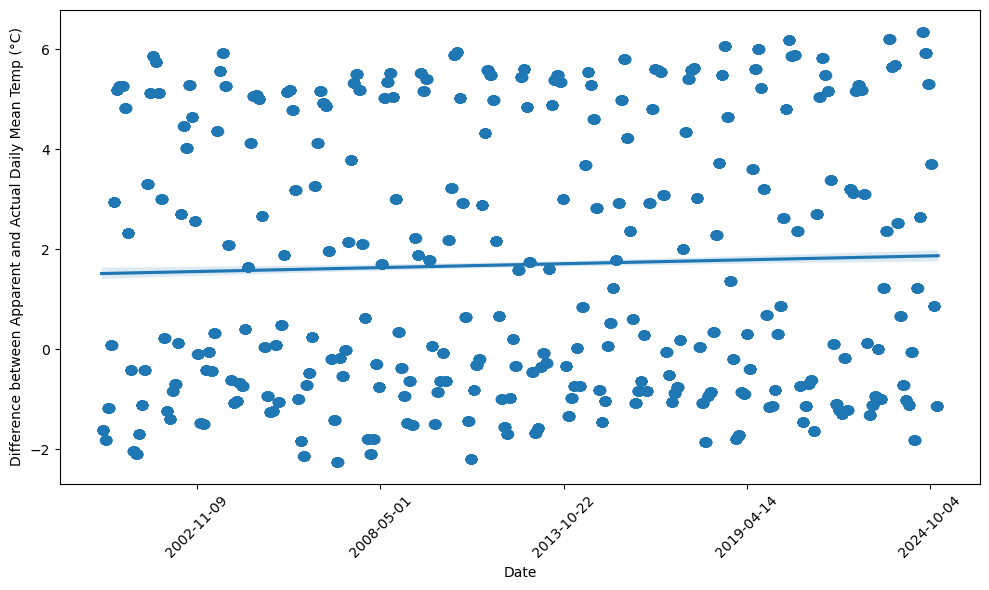

In [105]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df_lucknow, x='date_numeric', y='temp_diff_mean_monthly')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set(xlabel='Date', ylabel='Difference between Apparent and Actual Daily Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations

Cities located in the South of the country (Chennai, Bangalore, Hyderabad) exhibit more fluctuation throughout each year. Mumbai and Pune exhibit a similar pattern. The remaining cities show a more steady rise and fall in temperature differences. This may be due to the difference in humidity and precipitation levels.

Apparent temperatures are rarely 2°C colder than actual temperatures. The city of Chennai shows apparent temperatures consistently higher than actual ones. Mumbai, Kolkata, Bangalore and Hyderabad show apparent temperatures that are occasionally 1°C or less colder than actual ones. 

Delhi, Lucknow and Jaipur show seasonal patterns of colder apparent temperatures at the beginning of every year.

The difference between real and apparent daily mean temperatures in all cities appears to be increasing over the years, with the exception of Pune, which shows a steady, or even slight decrease in temperature differences. The city of Chennai shows the largest increase in temperature difference over the years. 


### Exploring Changing Temperature Differences for All Cities during Selected Years (2000, 2012 and 2024)

In [108]:
#create a subset for each year
df_2000 =  df[df['year']==2000]
df_2012 =  df[df['year']==2012]
df_2024 =  df[df['year']==2024]

### 2000

#### Daily Minimum and Maximum Temperature Difference (Monthly Average)

In [111]:
melted_minmax_2000 = df_2000.melt(
    id_vars='date',
    value_vars=['temp_diff_min', 'temp_diff_max'],
    var_name="Temperature_Level",
    value_name='Temp_Diff',
)

In [112]:
melted_minmax_2000['Temperature_Level'] = melted_minmax_2000['Temperature_Level'].replace(
    {'temp_diff_min': 'Difference between Apparent and Real Daily Minimum', 'temp_diff_max': 'Difference between Apparent and Real Daily Maximum'}
)

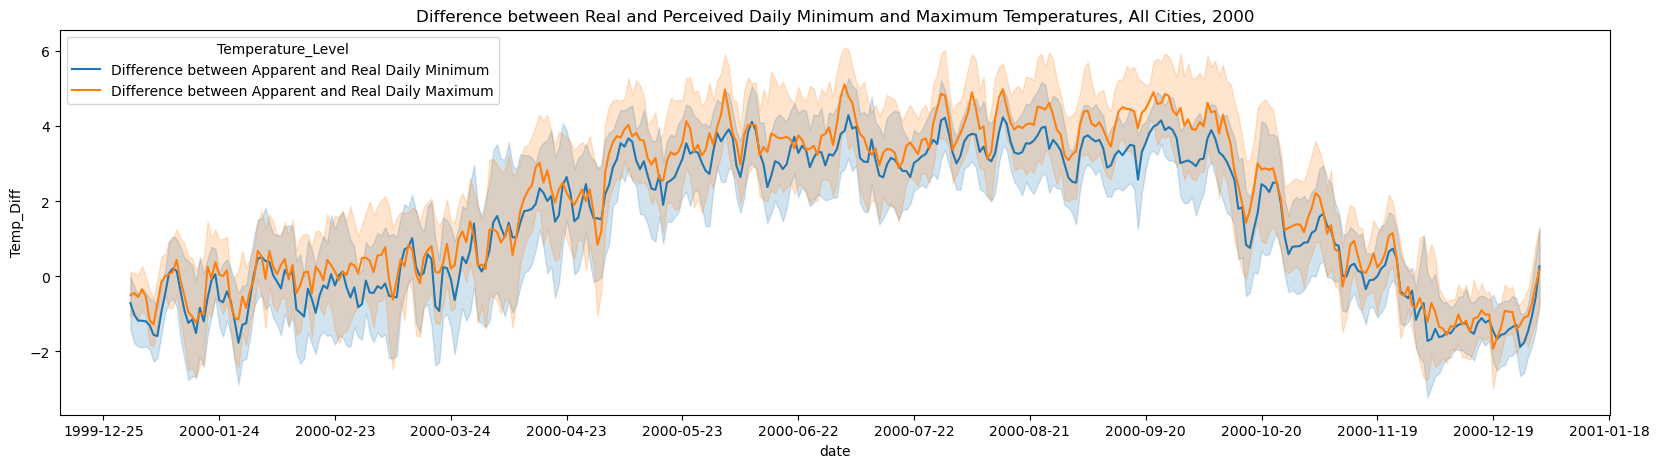

In [113]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_2000, x='date', y='Temp_Diff', hue='Temperature_Level')
ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
plt.title('Difference between Real and Perceived Daily Minimum and Maximum Temperatures, All Cities, 2000')
plt.show()

#### Daily Mean Temperature Difference in All Cities, 2000

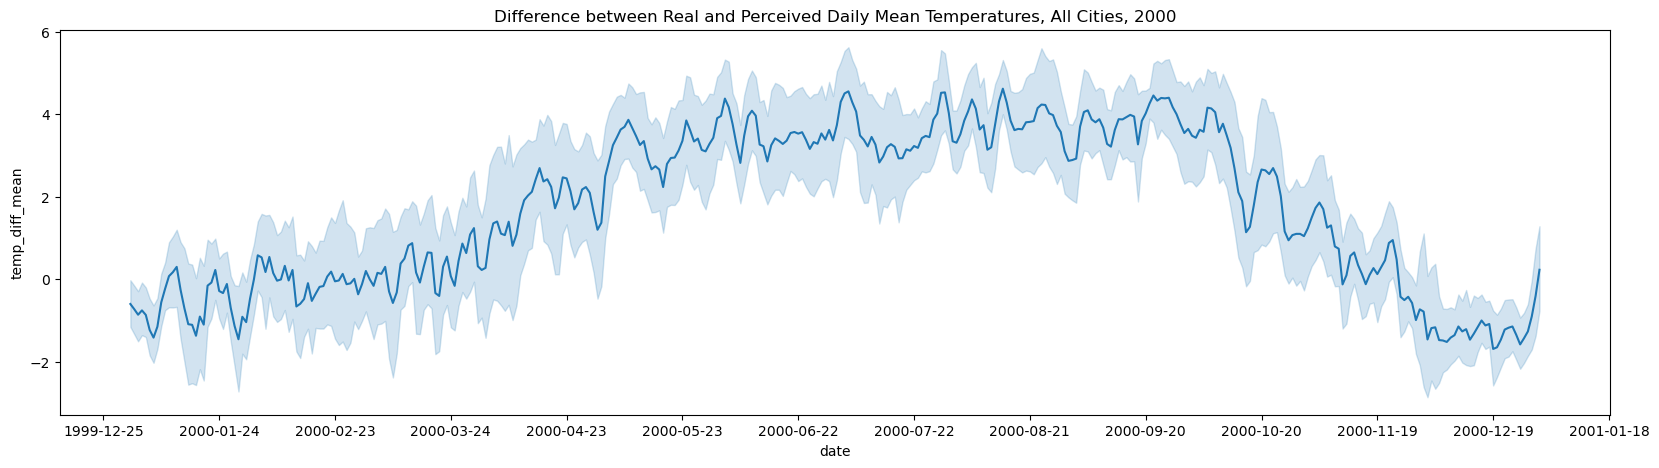

In [115]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_2000, x='date', y='temp_diff_mean')
ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
plt.title('Difference between Real and Perceived Daily Mean Temperatures, All Cities, 2000')
plt.show()

#### Finding Trends in Temperature Differences

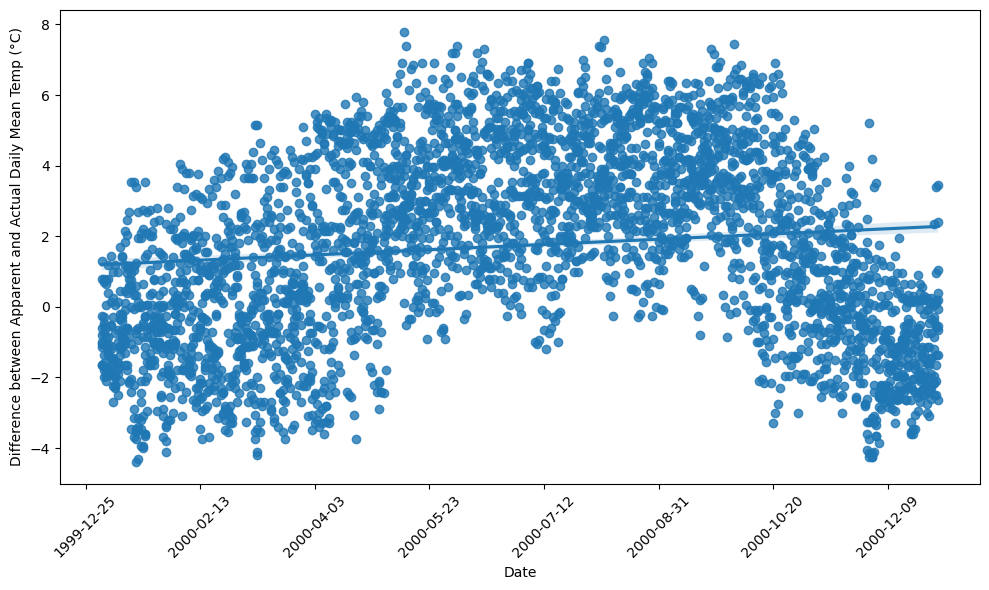

In [117]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df_2000, x='date_numeric', y='temp_diff_mean')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set(xlabel='Date', ylabel='Difference between Apparent and Actual Daily Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2012

#### Daily Minimum and Maximum Temperature Difference (Monthly Average)

In [120]:
melted_minmax_2012 = df_2012.melt(
    id_vars='date',
    value_vars=['temp_diff_min', 'temp_diff_max'],
    var_name="Temperature_Level",
    value_name='Temp_Diff',
)

In [121]:
melted_minmax_2012['Temperature_Level'] = melted_minmax_2012['Temperature_Level'].replace(
    {'temp_diff_min': 'Difference between Apparent and Real Daily Minimum', 'temp_diff_max': 'Difference between Apparent and Real Daily Maximum'}
)

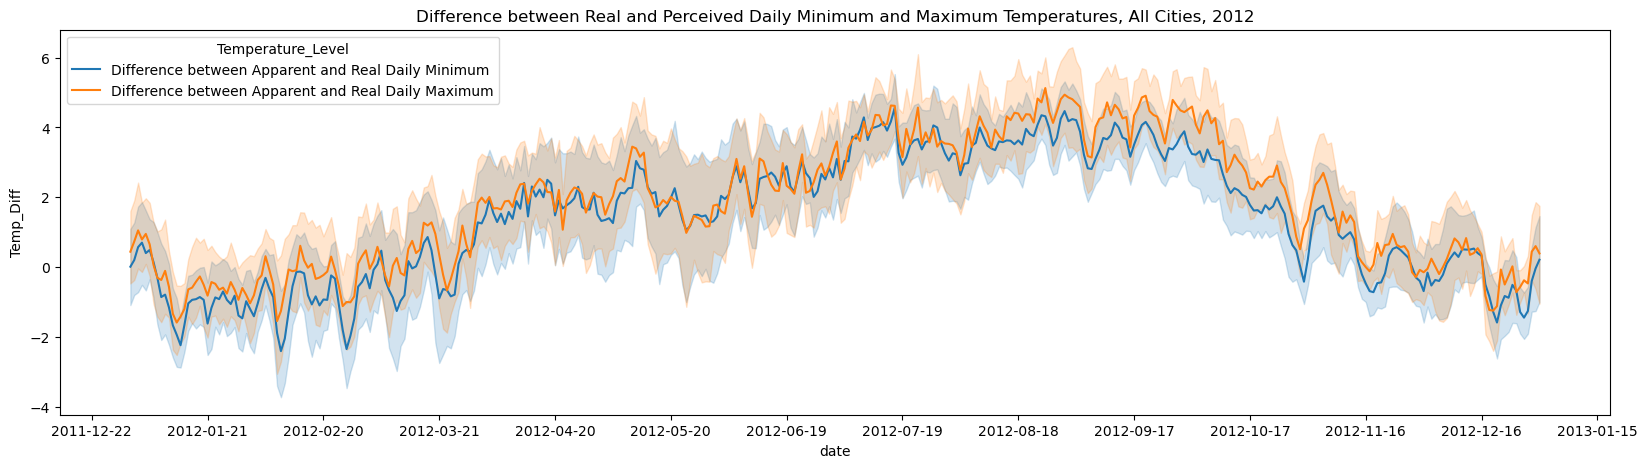

In [122]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_2012, x='date', y='Temp_Diff', hue='Temperature_Level')
ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
plt.title('Difference between Real and Perceived Daily Minimum and Maximum Temperatures, All Cities, 2012')
plt.show()

#### Daily Mean Temperature Difference in All Cities, 2012

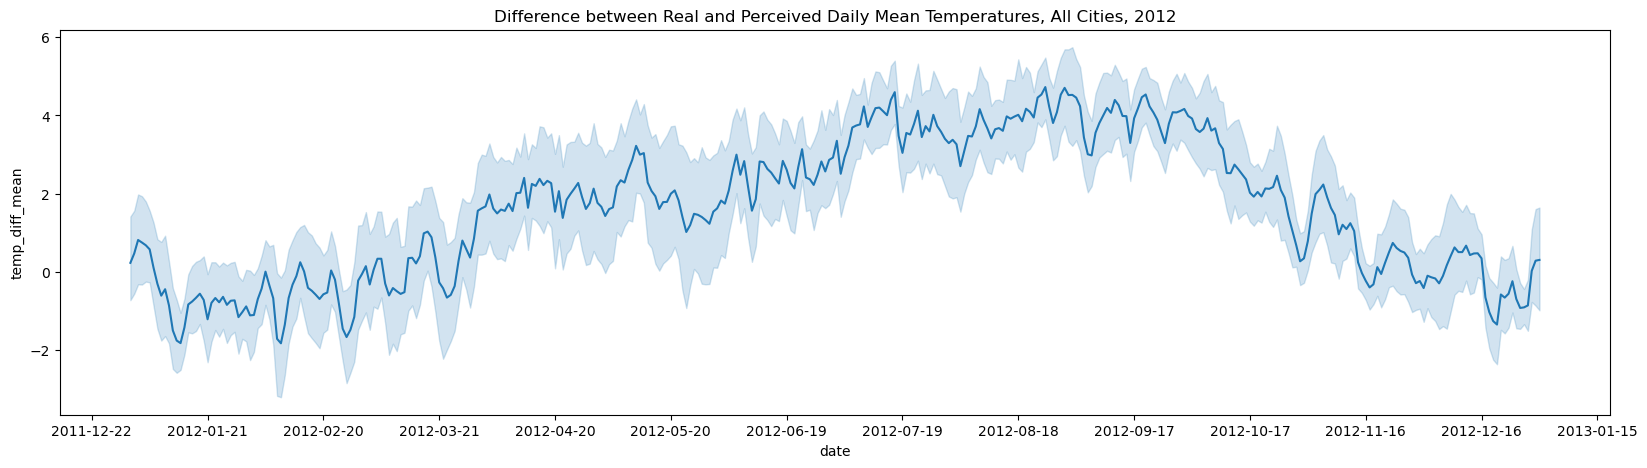

In [124]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_2012, x='date', y='temp_diff_mean')
ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
plt.title('Difference between Real and Perceived Daily Mean Temperatures, All Cities, 2012')
plt.show()

#### Finding Trends in Temperature Differences

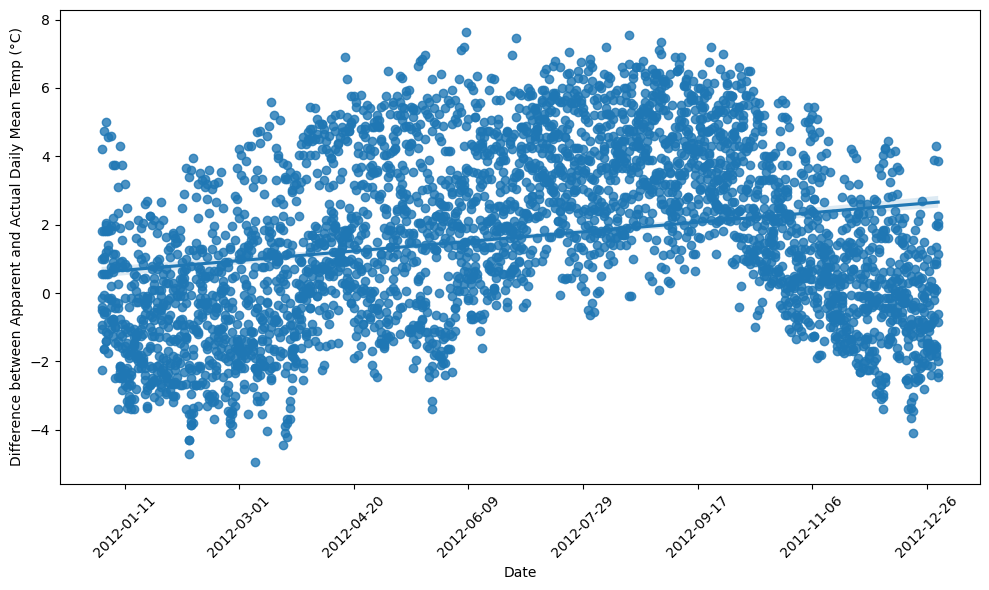

In [126]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df_2012, x='date_numeric', y='temp_diff_mean')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set(xlabel='Date', ylabel='Difference between Apparent and Actual Daily Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2024

#### Daily Minimum and Maximum Temperature Difference (Monthly Average)

In [129]:
melted_minmax_2024 = df_2024.melt(
    id_vars='date',
    value_vars=['temp_diff_min', 'temp_diff_max'],
    var_name="Temperature_Level",
    value_name='Temp_Diff',
)

In [130]:
melted_minmax_2024['Temperature_Level'] = melted_minmax_2024['Temperature_Level'].replace(
    {'temp_diff_min': 'Difference between Apparent and Real Daily Minimum', 'temp_diff_max': 'Difference between Apparent and Real Daily Maximum'}
)

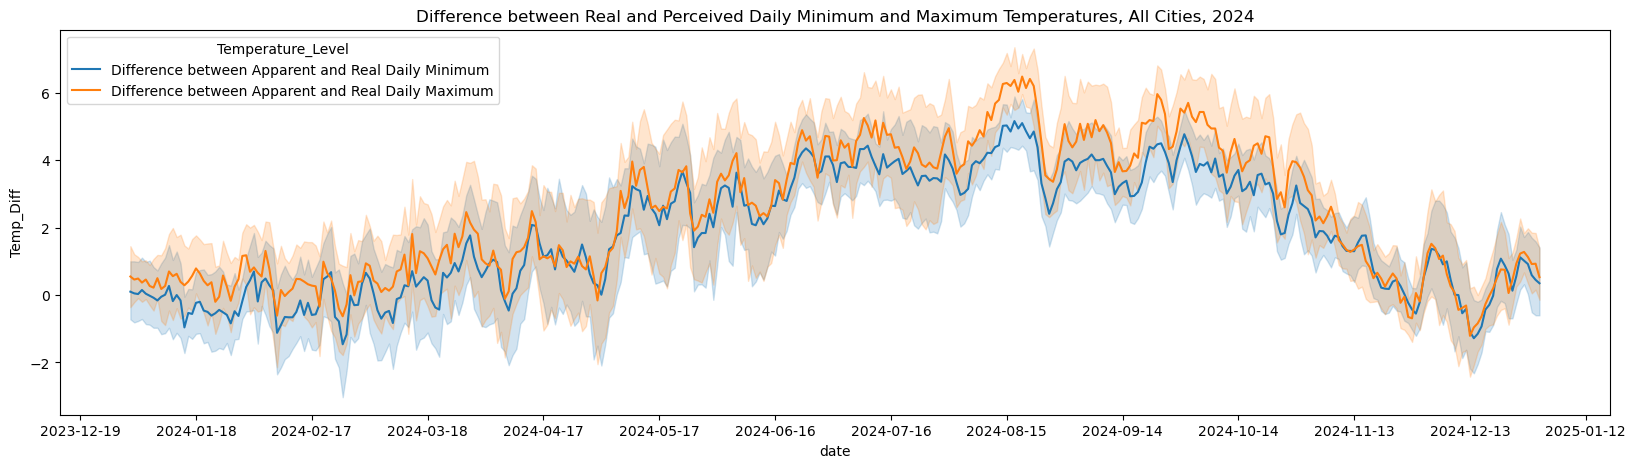

In [131]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=melted_minmax_2024, x='date', y='Temp_Diff', hue='Temperature_Level')
ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
plt.title('Difference between Real and Perceived Daily Minimum and Maximum Temperatures, All Cities, 2024')
plt.show()

#### Daily Mean Temperature Difference in All Cities, 2024

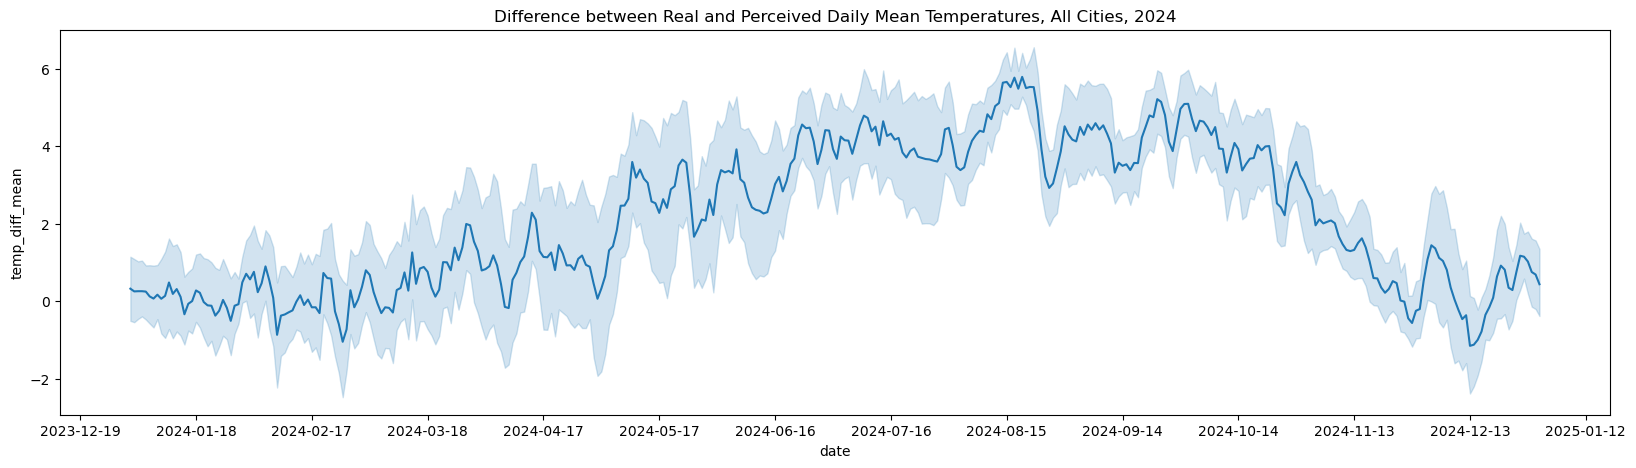

In [133]:
fig, ax = plt.subplots(figsize=(20,5))
sns.lineplot(data=df_2024, x='date', y='temp_diff_mean')
ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
plt.title('Difference between Real and Perceived Daily Mean Temperatures, All Cities, 2024')
plt.show()

#### Finding Trends in Temperature Differences

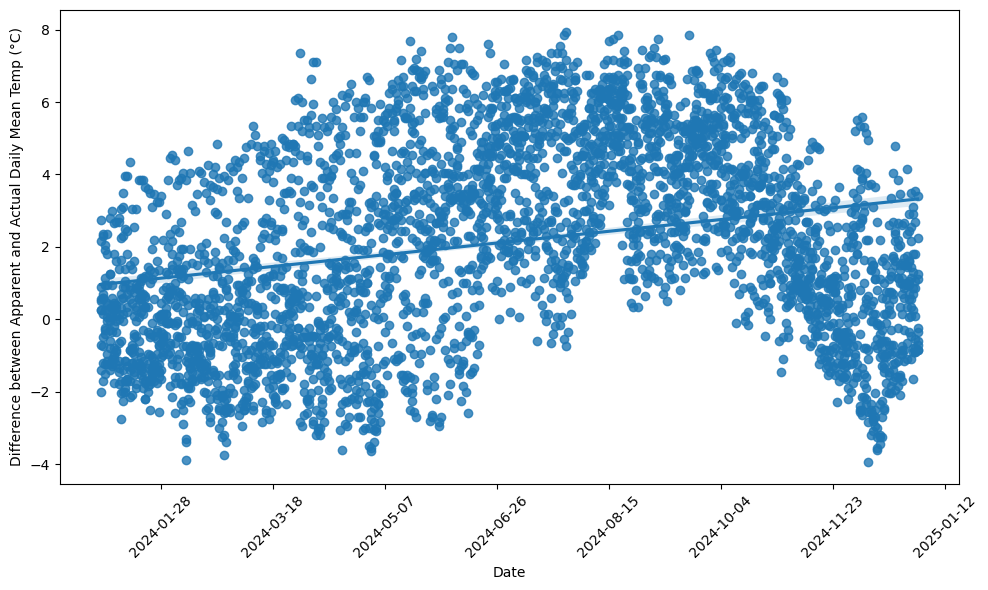

In [135]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df_2024, x='date_numeric', y='temp_diff_mean')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set(xlabel='Date', ylabel='Difference between Apparent and Actual Daily Mean Temp (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Observations

All 3 selected years showed a weakly increasing trend in temperature differences. However, linear regression is more useful for weather data spanning several years.

Years 2000 and 2012 showed more daily minimum, maximum and mean apparent temperatures cooler than actual temperatures.

All daily temperatures appear warmer during the summer and fall months of the year (June to November), likely corresponding with increased precipitation levels from the monsoon.

Actual and Perceived temperatures are almost the same during the winter months. Perceived temperatures cooler than actual ones are common during the winter and early spring months (January to April).